In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import Adam

In [2]:
column_names = ['sample_id', 'user', 'activity', 'timestamp', 'x', 'y', 'z']

# 2. 파일을 불러올 때 두 가지 중요한 옵션을 줍니다.
df = pd.read_csv(
    '/content/drive/MyDrive/WISDM.csv',
    header=None,
    names=column_names
)


In [3]:
df

,sample_id,user,activity,timestamp,x,y,z
0,0,33,Jogging,4.910600e+13,-0.694638,12.680544,0.503953
1,1,33,Jogging,4.910610e+13,5.012288,11.264028,0.953424
2,2,33,Jogging,4.910610e+13,4.903325,10.882658,-0.081722
3,3,33,Jogging,4.910620e+13,-0.612916,18.496431,3.023717
4,4,33,Jogging,4.910630e+13,-1.184970,12.108489,7.205164
...,...,...,...,...,...,...,...
1048570,1048571,7,Standing,2.091650e+14,-7.930000,5.430000,-0.990000
1048571,1048572,7,Standing,2.091660e+14,-7.970000,5.130000,-1.140000
1048572,1048573,7,Standing,2.091660e+14,-7.970000,5.220000,-1.380000
1048573,1048574,7,Standing,2.091660e+14,-7.930000,5.600000,-1.180000


In [4]:
df.shape

(1048575, 7)

In [5]:
df.isnull().values.any()

np.False_

In [6]:
df = df[(df['activity']=='Jogging') | (df['activity']=='Standing')]

In [7]:
df

,sample_id,user,activity,timestamp,x,y,z
0,0,33,Jogging,4.910600e+13,-0.694638,12.680544,0.503953
1,1,33,Jogging,4.910610e+13,5.012288,11.264028,0.953424
2,2,33,Jogging,4.910610e+13,4.903325,10.882658,-0.081722
3,3,33,Jogging,4.910620e+13,-0.612916,18.496431,3.023717
4,4,33,Jogging,4.910630e+13,-1.184970,12.108489,7.205164
...,...,...,...,...,...,...,...
1048570,1048571,7,Standing,2.091650e+14,-7.930000,5.430000,-0.990000
1048571,1048572,7,Standing,2.091660e+14,-7.970000,5.130000,-1.140000
1048572,1048573,7,Standing,2.091660e+14,-7.970000,5.220000,-1.380000
1048573,1048574,7,Standing,2.091660e+14,-7.930000,5.600000,-1.180000


In [8]:
LABELS = ["Normal", "Fraud"]

/tmp/ipython-input-3891906909.py:1: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  count_classes = pd.value_counts(df['activity'], sort = True)


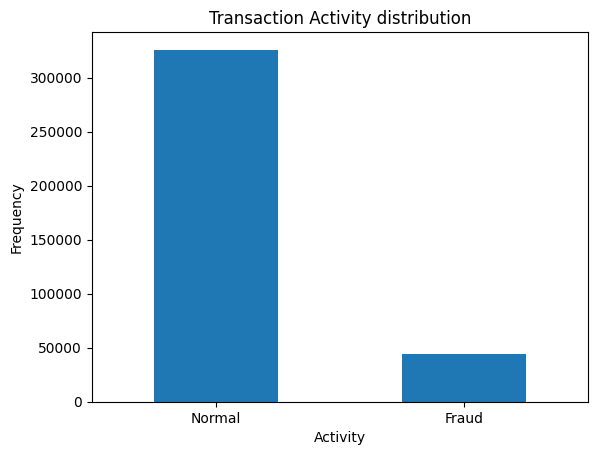

In [9]:
count_classes = pd.value_counts(df['activity'], sort = True)
count_classes.plot(kind = 'bar', rot=0)
plt.title("Transaction Activity distribution")
plt.xticks(range(2), LABELS)
plt.xlabel("Activity")
plt.ylabel("Frequency");

In [10]:
frauds = df[df.activity == 'Standing']
normal = df[df.activity == 'Jogging']
frauds.shape

(44547, 7)

In [11]:
normal.shape

(325975, 7)

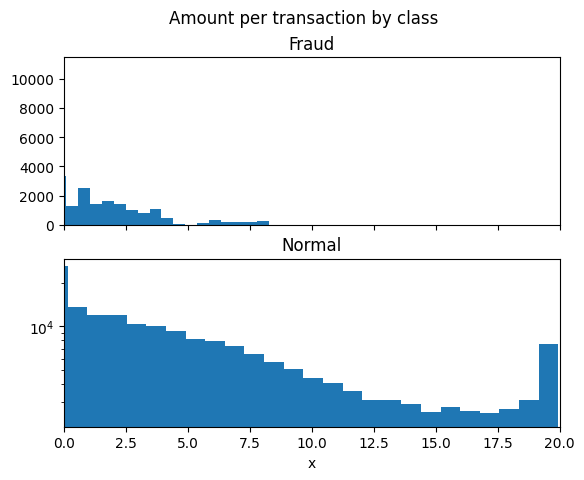

In [12]:
f, (ax1, ax2) = plt.subplots(2, 1, sharex=True)
f.suptitle('Amount per transaction by class')

bins = 50

ax1.hist(frauds.x, bins = bins)
ax1.set_title('Fraud')

ax2.hist(normal.x, bins = bins)
ax2.set_title('Normal')

plt.xlabel('x')
plt.ylabel('')
plt.xlim((0, 20))
plt.yscale('log')

plt.show()

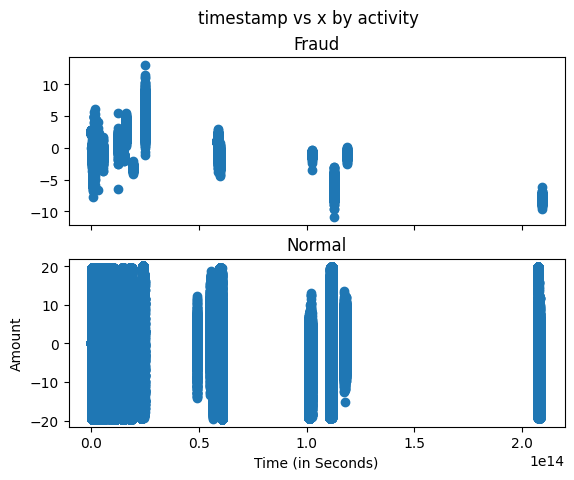

In [13]:
f, (ax1, ax2) = plt.subplots(2, 1, sharex=True)
f.suptitle('timestamp vs x by activity')

ax1.scatter(frauds.timestamp, frauds.x)
ax1.set_title('Fraud')

ax2.scatter(normal.timestamp, normal.x)
ax2.set_title('Normal')

plt.xlabel('Time (in Seconds)')
plt.ylabel('Amount')
plt.show()

In [14]:
from sklearn.preprocessing import StandardScaler

data = df.drop(['timestamp'], axis=1)

data['x'] = StandardScaler().fit_transform(data['x'].values.reshape(-1, 1))

In [15]:
RANDOM_SEED = 42

In [16]:
X_train, X_test = train_test_split(data, test_size=0.2, random_state=RANDOM_SEED)
X_train = X_train[X_train.activity == 'Jogging']
X_train = X_train.drop(['activity'], axis=1)

y_test = X_test['activity']
X_test = X_test.drop(['activity'], axis=1)

X_train = X_train.values
X_test = X_test.values

X_train.shape

(260902, 5)

In [17]:
# 오토인코더 모델

input_dim = X_train.shape[1]
encoding_dim = 14  # 인코딩 차원을 설정 (임의로 설정한 값, 조정 가능)

input_layer = Input(shape=(input_dim,))
encoded = Dense(encoding_dim, activation='relu')(input_layer)
encoded = Dense(int(encoding_dim / 2), activation='relu')(encoded)
decoded = Dense(int(encoding_dim / 2), activation='relu')(encoded)
decoded = Dense(input_dim, activation='sigmoid')(decoded)

autoencoder = Model(inputs=input_layer, outputs=decoded)
autoencoder.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

In [18]:
# 3. 모델 학습
# 훈련데이터의 0.1 을 validation data로 사용
history = autoencoder.fit(X_train, X_train,
                          epochs=50,
                          batch_size=256,
                          shuffle=True,
                          validation_split = 0.1)

Epoch 1/50
918/918 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - loss: 70655852544.0000 - val_loss: 70288515072.0000
Epoch 2/50
918/918 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 70972571648.0000 - val_loss: 70288515072.0000
Epoch 3/50
918/918 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 70659145728.0000 - val_loss: 70288515072.0000
Epoch 4/50
918/918 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 70258556928.0000 - val_loss: 70288515072.0000
Epoch 5/50
918/918 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 70465437696.0000 - val_loss: 70288515072.0000
Epoch 6/50
918/918 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 70588350464.0000 - val_loss: 70288515072.0000
Epoch 7/50
918/918 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 70541131776.0000 - val_loss: 70288515072.0000
Epoch 8/50
918/918 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 70585909248.0000 - val_loss: 70288515072.0000
Epoch 9/50
918/918 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 70397509632.0000 - val_loss: 70288515072.0000
Epoch 10/50
918/918 ━━━━━━━━━━━━━━━━━━━━ 4s 5m

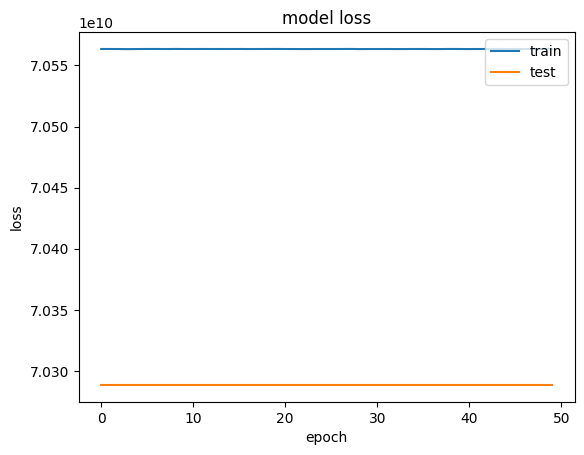

In [19]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper right');

In [20]:
# X_test 값을 넣어서 Reconstruction Error 값을 얻고,
# 실제 레이블인 y_test와 데이터프레임으로 구성
# Reconstruction Error + 실제 레이블의 형태가 됨

predictions = autoencoder.predict(X_test)
mse = np.mean(np.power(X_test - predictions, 2), axis=1)
error_df = pd.DataFrame({'reconstruction_error': mse,
                        'true_class': y_test})
error_df.describe()

2316/2316 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step


,reconstruction_error
count,7.410500e+04
mean,7.199137e+10
std,6.535461e+10
min,2.248219e+02
25%,1.169306e+10
50%,5.708397e+10
75%,1.198313e+11
max,2.198960e+11


In [21]:
error_df.head()

,reconstruction_error,true_class
615245,7.570528e+10,Standing
1022650,2.091626e+11,Jogging
107350,2.304762e+09,Jogging
257348,1.324550e+10,Jogging
762305,1.162218e+11,Jogging


In [22]:
threshold = 15

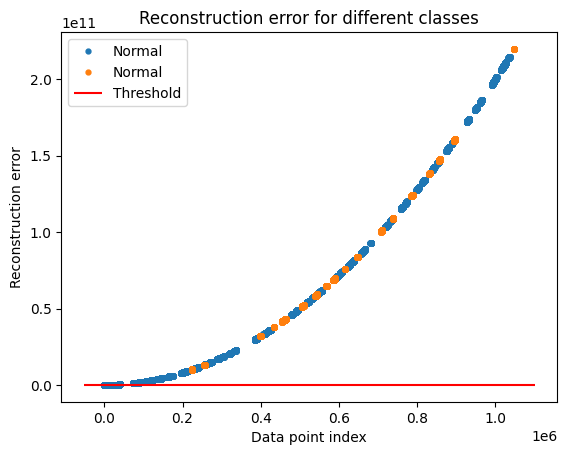

In [23]:
groups = error_df.groupby('true_class')
fig, ax = plt.subplots()

for name, group in groups:
    ax.plot(group.index, group.reconstruction_error, marker='o', ms=3.5, linestyle='',
            label= "Fraud" if name == 1 else "Normal")
ax.hlines(threshold, ax.get_xlim()[0], ax.get_xlim()[1], colors="r", zorder=100, label='Threshold')
ax.legend()
plt.title("Reconstruction error for different classes")
plt.ylabel("Reconstruction error")
plt.xlabel("Data point index")
plt.show();

In [24]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

y_pred = [1 if e > threshold else 0 for e in error_df.reconstruction_error.values]
conf_matrix = confusion_matrix(error_df.true_class, y_pred)
plt.figure(figsize=(8, 8))
sns.heatmap(conf_matrix, xticklabels=LABELS, yticklabels=LABELS, annot=True, fmt="d");
plt.title("Confusion matrix")
plt.ylabel('True class')
plt.xlabel('Predicted class')
plt.show()

print(classification_report(error_df.true_class, y_pred))

TypeError: Labels in y_true and y_pred should be of the same type. Got y_true=['Jogging' 'Standing'] and y_pred=[1]. Make sure that the predictions provided by the classifier coincides with the true labels.